In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns

In [2]:
# ========================
# 0. 設定路徑（請依你的實際檔案調整）
# ========================
folder = Path("C:/Users/AW'z/Downloads/ballet_Analysis_Results/260201__analysis_metrics/26020105_analysis_metrics/")

json_file      = folder / "ceremony_dialogue_2026020105.json"
energy_file    = folder / "energy.csv"
geometry_file  = folder / "geometry.csv"
stability_file = folder / "stability.csv"
sync_file      = folder / "synchronization.csv"
trans_file     = folder / "transition.csv"
skeleton_file  = folder / "26020105_skeleton.csv"

In [3]:
# ========================
# 1. 讀取 GPT JSON 並提取輪次資訊
# ========================
with open(json_file, 'r', encoding='utf-8') as f:
    gpt = json.load(f)

dialogue = gpt.get("dialogue", [])
turns = []
for d in dialogue:
    ai_response = d["ai_response"]
    
    # 取出 【AI sees】 部分
    if "【AI sees】" in ai_response:
        sees_part = ai_response.split("【AI sees】")[-1]
        if "【AI says】" in sees_part:
            sees_part = sees_part.split("【AI says】")[0]
        sees_part = sees_part.strip()
    else:
        sees_part = ""
    
    turns.append({
        "turn": d["turn"],
        "frame": d["frame"],
        "sec": d["timestamp_sec"],
        "ai_sees_short": sees_part[:180] + ("..." if len(sees_part) > 180 else ""),  # 只取 AI sees
        "ai_says_short": ai_response.split("【AI says】")[-1].strip()[:80] if "【AI says】" in ai_response else ""  # 可選保留 says
    })

turns_df = pd.DataFrame(turns)
print("=== GPT 對話輪次摘要（重點顯示 AI sees 視覺描述） ===")
print(f"總輪次：{len(turns_df)}")
print(turns_df[["turn", "sec", "frame", "ai_sees_short"]])

=== GPT 對話輪次摘要（重點顯示 AI sees 視覺描述） ===
總輪次：6
   turn   sec  frame                                      ai_sees_short
0     1   0.0      0          他如同青鳥在空中翱翔，瞬間的足尖敲擊如同音樂的脈搏，帶著自由與生命的旋律交織而舞。
1     2   2.0     60  在無拘無束的空間中，你的身體如同那位舞王般，以極具張力的fouetté撕裂著空氣，展現出現代...
2     3   4.0    120  在如畫的背景幕前，你的肢體以雄壯的arabesque描繪著劇情的深度與情感，彷彿在訴說著命運...
3     4   6.0    180  你的身體如同月光下的輪廓，微妙的hyper-extension在舞動中繪製出纖長的線條，表現...
4     5   8.0    240  你的身體如同夢境中的精靈，纖細的arabesque與強勁的plié交織，彷彿在訴說一個奇幻的...
5     6  10.0    300  在空中那瞬間的assemblé，雙腿如同利刃歸鞘，完美的收束展現出力量的匯聚，彷彿在奏響一首...


In [4]:
# ========================
# 2. 讀取並合併所有指標 CSV
# ========================
print("\n=== 讀取與合併 CSV ===")
dfs = {}
for name, file in [
    ("energy", energy_file),
    ("geometry", geometry_file),
    ("stability", stability_file),
    ("sync", sync_file),
    ("trans", trans_file)
]:
    if file.exists():
        df = pd.read_csv(file)
        df["frame"] = range(len(df))          # 若無 frame 欄位則新增
        df["sec"] = df["frame"] / 30.0        # 假設 30 fps（與你的 JSON 一致）
        dfs[name] = df
        print(f"{name}: {len(df)} 行")
    else:
        print(f"警告：{file} 不存在")

# 合併（以 frame 為鍵）
merged = dfs["energy"][["frame", "sec", "energy"]].copy()
for name in ["geometry", "stability", "sync", "trans"]:
    if name in dfs:
        merged = merged.merge(
            dfs[name].drop(columns=["sec"] if "sec" in dfs[name].columns else []),
            on="frame", how="outer"
        )

# 填補缺失值（前向填充 + 0）
merged = merged.fillna(method="ffill").fillna(0)


=== 讀取與合併 CSV ===
energy: 319 行
geometry: 319 行
stability: 319 行
sync: 319 行
trans: 319 行


C:\Users\AW'z\AppData\Local\Temp\ipykernel_18336\2309931909.py:32: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged = merged.fillna(method="ffill").fillna(0)


In [5]:
# ========================
# 3. 讀 skeleton.csv 檢查一致性（可選擴充）
# ========================
if skeleton_file.exists():
    skel = pd.read_csv(skeleton_file)
    print(f"skeleton 總 frame：{len(skel)}")
    # 未來可在此計算自訂特徵，例如重心高度驗證
else:
    print("skeleton.csv 未找到，跳過骨架驗證")

skeleton 總 frame：319


In [6]:
# ========================
# 4. 計算 Ballet 關鍵統計
# ========================
stats = {
    "總秒數": f"{merged['sec'].max():.1f} 秒",
    "Energy Mean / Peak": f"{merged['energy'].mean():.2f} / {merged['energy'].max():.2f}",
    "Volume Mean / Max": f"{merged['volume'].mean():.3f} / {merged['volume'].max():.3f}",
    "Curvature Mean": f"{merged['curvature'].mean():.2f}",
    "Height Mean / Range": f"{merged['height'].mean():.3f} ({merged['height'].min():.3f} ~ {merged['height'].max():.3f})",
    "Sway Mean": f"{merged['sway'].mean():.3f}",
    "Sync Correlation Mean": f"{merged['correlation'].mean():.3f} (有效部分)",
    "Jerk Peak": f"{merged['jerk'].max():.0f}"
}

print("\n=== Ballet 關鍵統計 ===")
for k, v in stats.items():
    print(f"{k:20}: {v}")


=== Ballet 關鍵統計 ===
總秒數                 : 10.6 秒
Energy Mean / Peak  : 0.71 / 4.24
Volume Mean / Max   : 0.073 / 0.133
Curvature Mean      : 8.34
Height Mean / Range : 0.905 (0.743 ~ 1.008)
Sway Mean           : 0.081
Sync Correlation Mean: 0.272 (有效部分)
Jerk Peak           : 19677


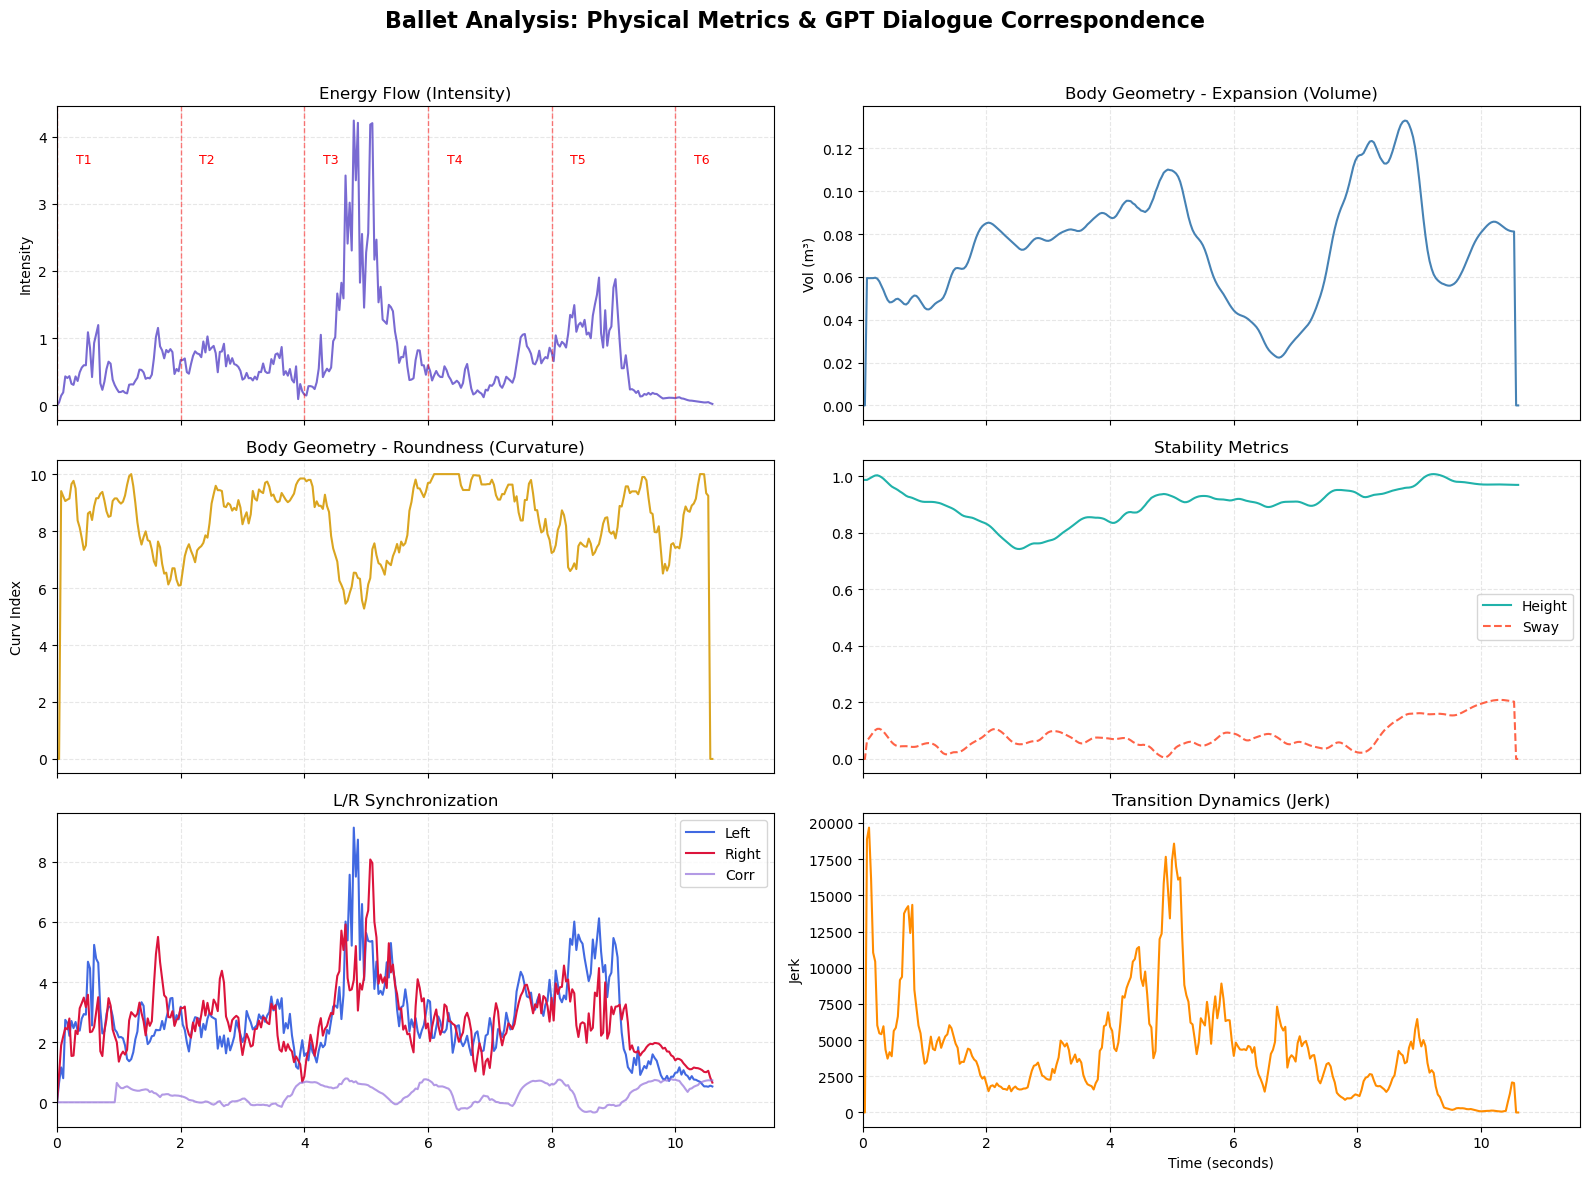


圖表已儲存：all_metrics_with_gpt_turns.png


In [7]:
# ========================
# 5. 繪製多子圖
# ========================
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
fig.suptitle("Ballet Analysis: Physical Metrics & GPT Dialogue Correspondence", fontsize=16, fontweight='bold')

axs = axes.flatten()

# (1) Energy Flow
axs[0].plot(merged["sec"], merged["energy"], color="#6A5ACD", linewidth=1.5, alpha=0.9)  # 優雅紫
axs[0].set_title("Energy Flow (Intensity)", fontsize=12)
axs[0].set_ylabel("Intensity")
for _, row in turns_df.iterrows():
    axs[0].axvline(row["sec"], color="red", linestyle="--", alpha=0.5, linewidth=1)
    axs[0].text(row["sec"]+0.3, merged["energy"].max()*0.85, f"T{row['turn']}", fontsize=9, color="red")

# (2) Body Geometry - Expansion (Volume)
axs[1].plot(merged["sec"], merged["volume"], color="#4682B4")  # 鋼藍
axs[1].set_title("Body Geometry - Expansion (Volume)", fontsize=12)
axs[1].set_ylabel("Vol (m³)")

# (3) Body Geometry - Roundness (Curvature)
axs[2].plot(merged["sec"], merged["curvature"], color="#DAA520")  # 金色
axs[2].set_title("Body Geometry - Roundness (Curvature)", fontsize=12)
axs[2].set_ylabel("Curv Index")

# (4) Stability Metrics (Height & Sway)
axs[3].plot(merged["sec"], merged["height"], color="#20B2AA", label="Height")
axs[3].plot(merged["sec"], merged["sway"], color="#FF6347", linestyle="--", label="Sway")
axs[3].set_title("Stability Metrics", fontsize=12)
axs[3].legend()

# (5) L/R Synchronization
axs[4].plot(merged["sec"], merged["left"], color="#4169E1", label="Left")
axs[4].plot(merged["sec"], merged["right"], color="#DC143C", label="Right")
axs[4].plot(merged["sec"], merged["correlation"], color="#9370DB", alpha=0.7, label="Corr")
axs[4].set_title("L/R Synchronization", fontsize=12)
axs[4].legend()

# (6) Transition Dynamics (Jerk)
axs[5].plot(merged["sec"], merged["jerk"], color="#FF8C00")
axs[5].set_title("Transition Dynamics (Jerk)", fontsize=12)
axs[5].set_ylabel("Jerk")
axs[5].set_xlabel("Time (seconds)")

# 美化
for ax in axs:
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(0, merged["sec"].max() + 1)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("all_metrics_with_gpt_turns.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n圖表已儲存：all_metrics_with_gpt_turns.png")